# Phần 3: Machine Learning
Nhóm: E_DATA

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [8]:
train     = pd.read_csv('sales.csv',        parse_dates=['Date'])
test      = pd.read_csv('sample_submission.csv', parse_dates=['Date'])
inventory = pd.read_csv('inventory.csv',    parse_dates=['snapshot_date'])
traffic   = pd.read_csv('web_traffic.csv',  parse_dates=['date'])
promos    = pd.read_csv('promotions.csv',   parse_dates=['start_date','end_date'])

print('Train:', train.shape, '|', train['Date'].min().date(), '→', train['Date'].max().date())
print('Test :', test.shape,  '|', test['Date'].min().date(),  '→', test['Date'].max().date())
train.head()

Train: (3833, 3) | 2012-07-04 → 2022-12-31
Test : (548, 3) | 2023-01-01 → 2024-07-01


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [10]:
def make_date_features(df):
    df = df.copy()
    df['year']        = df['Date'].dt.year
    df['month']       = df['Date'].dt.month
    df['day']         = df['Date'].dt.day
    df['dayofweek']   = df['Date'].dt.dayofweek      # 0=Thứ 2, 6=Chủ nhật
    df['dayofyear']   = df['Date'].dt.dayofyear
    df['weekofyear']  = df['Date'].dt.isocalendar().week.astype(int)
    df['quarter']     = df['Date'].dt.quarter
    df['is_weekend']  = (df['Date'].dt.dayofweek >= 5).astype(int)
    df['is_month_end']   = df['Date'].dt.is_month_end.astype(int)
    df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)

    # Ngày lễ Việt Nam quan trọng
    df['is_tet'] = (
        ((df['month'] == 1) & (df['day'].between(20, 31))) |
        ((df['month'] == 2) & (df['day'].between(1, 10)))
    ).astype(int)
    df['is_916']       = ((df['month'] == 9)  & (df['day'] == 16)).astype(int)
    df['is_1111']      = ((df['month'] == 11) & (df['day'] == 11)).astype(int)
    df['is_black_fri'] = ((df['month'] == 11) & (df['day'].between(25, 30))).astype(int)
    df['is_1212']      = ((df['month'] == 12) & (df['day'] == 12)).astype(int)
    df['is_yearend']   = ((df['month'] == 12) & (df['day'].between(25, 31))).astype(int)

    return df

train = make_date_features(train)
test  = make_date_features(test)

print('Date features xong:', [c for c in train.columns if c not in ['Date','Revenue','COGS']])

Date features xong: ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_end', 'is_month_start', 'is_tet', 'is_916', 'is_1111', 'is_black_fri', 'is_1212', 'is_yearend']


In [13]:
# Sắp xếp theo ngày
train = train.sort_values('Date').reset_index(drop=True)

# Lag features: doanh thu X ngày trước
# Chỉ dùng lag >= 365 để tránh data leakage khi predict tương lai
for lag in [365, 366, 730]:
    train[f'rev_lag_{lag}']  = train['Revenue'].shift(lag)
    train[f'cogs_lag_{lag}'] = train['COGS'].shift(lag)

# Rolling mean: trung bình 7/30 ngày của NĂM NGOÁI (tránh leakage)
train['rev_roll7_lag365']  = train['Revenue'].shift(365).rolling(7,  min_periods=1).mean()
train['rev_roll30_lag365'] = train['Revenue'].shift(365).rolling(30, min_periods=1).mean()
train['rev_roll90_lag365'] = train['Revenue'].shift(365).rolling(90, min_periods=1).mean()

# Tỷ lệ tháng hiện tại so với cùng tháng năm ngoái
monthly_avg = train.groupby(['year','month'])['Revenue'].transform('mean')
train['rev_monthly_avg'] = monthly_avg

print('Lag features xong')
print(f'Rows sau khi drop NaN lag: {train.dropna().shape[0]} / {len(train)}')

Lag features xong
Rows sau khi drop NaN lag: 3103 / 3833


In [14]:
# Aggregate traffic theo ngày (vì có nhiều nguồn traffic mỗi ngày)
traffic_daily = traffic.groupby('date').agg(
    total_sessions    = ('sessions', 'sum'),
    total_visitors    = ('unique_visitors', 'sum'),
    total_pageviews   = ('page_views', 'sum'),
    avg_bounce_rate   = ('bounce_rate', 'mean'),
    avg_duration      = ('avg_session_duration_sec', 'mean')
).reset_index().rename(columns={'date': 'Date'})

# Lag traffic 1 ngày (traffic hôm qua → doanh thu hôm nay)
traffic_daily = traffic_daily.sort_values('Date')
for col in ['total_sessions', 'total_visitors', 'avg_bounce_rate']:
    traffic_daily[f'{col}_lag1'] = traffic_daily[col].shift(1)

# Merge vào train và test
train = train.merge(traffic_daily, on='Date', how='left')
test  = test.merge(traffic_daily, on='Date', how='left')

print('Traffic features xong')
print('Columns mới:', [c for c in traffic_daily.columns if c != 'Date'])

Traffic features xong
Columns mới: ['total_sessions', 'total_visitors', 'total_pageviews', 'avg_bounce_rate', 'avg_duration', 'total_sessions_lag1', 'total_visitors_lag1', 'avg_bounce_rate_lag1']


In [15]:
def get_promo_features(df, promos):
    df = df.copy()
    
    # Đếm số promo đang active mỗi ngày
    def count_active_promos(date):
        active = promos[
            (promos['start_date'] <= date) & 
            (promos['end_date']   >= date)
        ]
        return len(active)
    
    def sum_active_discount(date):
        active = promos[
            (promos['start_date'] <= date) & 
            (promos['end_date']   >= date) &
            (promos['promo_type'] == 'percentage')
        ]
        return active['discount_value'].sum() if len(active) > 0 else 0

    df['n_active_promos']    = df['Date'].apply(count_active_promos)
    df['total_pct_discount'] = df['Date'].apply(sum_active_discount)
    df['has_promo']          = (df['n_active_promos'] > 0).astype(int)
    
    return df

train = get_promo_features(train, promos)
test  = get_promo_features(test,  promos)
print('Promo features xong')

Promo features xong


In [16]:
# Aggregate inventory theo tháng
inv_monthly = inventory.groupby(['year','month']).agg(
    avg_stockout_days = ('stockout_days', 'mean'),
    avg_fill_rate     = ('fill_rate', 'mean'),
    pct_stockout      = ('stockout_flag', 'mean'),
    avg_sell_through  = ('sell_through_rate', 'mean')
).reset_index()

train = train.merge(inv_monthly, on=['year','month'], how='left')
test  = test.merge(inv_monthly, on=['year','month'], how='left')

print('Inventory features xong')

Inventory features xong


In [17]:
# Features dùng để train
FEATURE_COLS = [
    # Date features
    'year','month','day','dayofweek','dayofyear','quarter',
    'is_weekend','is_month_end','is_month_start',
    'is_tet','is_1111','is_black_fri','is_1212','is_yearend',
    # Lag features
    'rev_lag_365','rev_lag_366','rev_lag_730',
    'rev_roll7_lag365','rev_roll30_lag365','rev_roll90_lag365',
    'rev_monthly_avg',
    # Traffic
    'total_sessions','total_visitors','avg_bounce_rate',
    'total_sessions_lag1','total_visitors_lag1',
    # Promo
    'n_active_promos','total_pct_discount','has_promo',
    # Inventory
    'avg_stockout_days','avg_fill_rate','pct_stockout','avg_sell_through'
]

# Chỉ lấy rows có đủ data (lag 365 cần ít nhất 1 năm data)
train_clean = train.dropna(subset=['rev_lag_365']).copy()

X_train = train_clean[FEATURE_COLS]
y_rev   = train_clean['Revenue']
y_cogs  = train_clean['COGS']

print(f'Training rows: {len(X_train):,}')
print(f'Features: {len(FEATURE_COLS)}')

# ---- Train Revenue model ----
params = {
    'objective'   : 'regression',
    'metric'      : 'mae',
    'learning_rate': 0.05,
    'num_leaves'  : 63,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'verbose'         : -1,
    'random_state'    : 42
}

# TimeSeriesSplit: validation = 2 năm cuối (2021-2022)
cutoff = pd.Timestamp('2021-01-01')
X_tr = X_train[train_clean['Date'] < cutoff]
X_val = X_train[train_clean['Date'] >= cutoff]
y_tr_rev  = y_rev[train_clean['Date'] < cutoff]
y_val_rev = y_rev[train_clean['Date'] >= cutoff]

dtrain_rev = lgb.Dataset(X_tr,  label=y_tr_rev)
dval_rev   = lgb.Dataset(X_val, label=y_val_rev, reference=dtrain_rev)

model_rev = lgb.train(
    params,
    dtrain_rev,
    num_boost_round=1000,
    valid_sets=[dval_rev],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# ---- Train COGS model ----
y_tr_cogs  = y_cogs[train_clean['Date'] < cutoff]
y_val_cogs = y_cogs[train_clean['Date'] >= cutoff]

dtrain_cogs = lgb.Dataset(X_tr,  label=y_tr_cogs)
dval_cogs   = lgb.Dataset(X_val, label=y_val_cogs, reference=dtrain_cogs)

model_cogs = lgb.train(
    params,
    dtrain_cogs,
    num_boost_round=1000,
    valid_sets=[dval_cogs],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

print('\nTraining xong!')

Training rows: 3,468
Features: 33
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 641557
[200]	valid_0's l1: 631485
Early stopping, best iteration is:
[218]	valid_0's l1: 629087
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 551266
[200]	valid_0's l1: 545405
Early stopping, best iteration is:
[166]	valid_0's l1: 543966

Training xong!


Validation Metrics (2021–2022):
   Revenue MAE  : 629,087
   Revenue RMSE : 891,914
   Revenue R²   : 0.7137


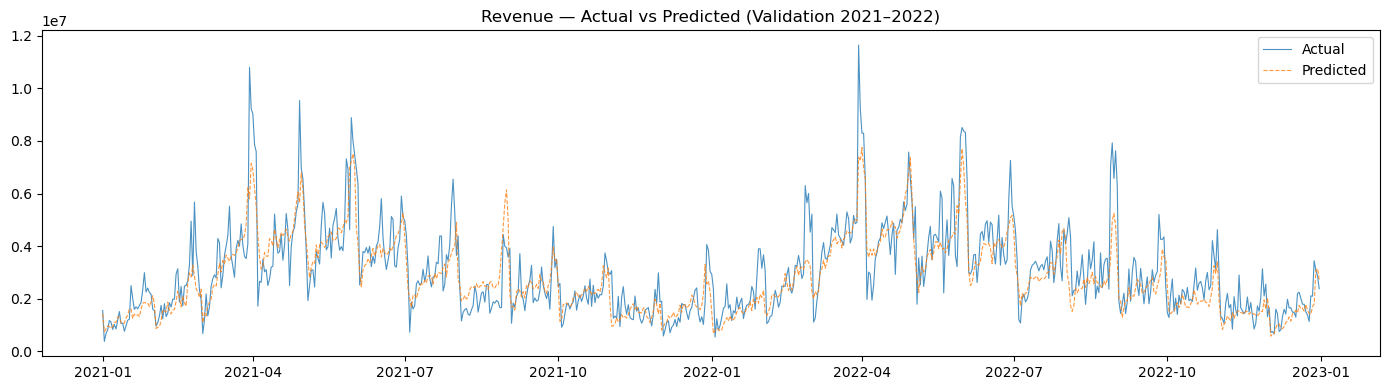

In [21]:
val_data = train_clean[train_clean['Date'] >= cutoff].copy()
val_pred_rev  = model_rev.predict(val_data[FEATURE_COLS])
val_pred_cogs = model_cogs.predict(val_data[FEATURE_COLS])

mae_rev  = mean_absolute_error(val_data['Revenue'], val_pred_rev)
mse_rev = mean_squared_error(val_data['Revenue'], val_pred_rev)
rmse_rev = np.sqrt(mse_rev)
r2_rev   = r2_score(val_data['Revenue'], val_pred_rev)

print('Validation Metrics (2021–2022):')
print(f'   Revenue MAE  : {mae_rev:,.0f}')
print(f'   Revenue RMSE : {rmse_rev:,.0f}')
print(f'   Revenue R²   : {r2_rev:.4f}')

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val_data['Date'], val_data['Revenue'],  lw=0.8, label='Actual',    alpha=0.8)
ax.plot(val_data['Date'], val_pred_rev,          lw=0.8, label='Predicted', alpha=0.8, linestyle='--')
ax.set_title('Revenue — Actual vs Predicted (Validation 2021–2022)')
ax.legend()
plt.tight_layout()
plt.show()

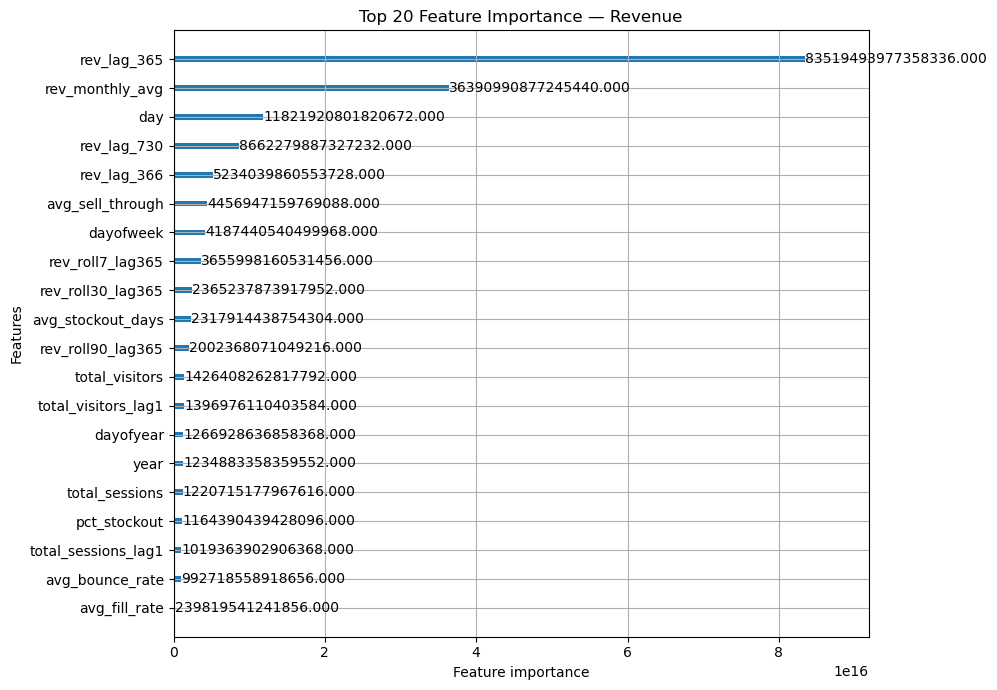


Top 10 features:
          feature   importance
      rev_lag_365 8.351949e+16
  rev_monthly_avg 3.639099e+16
              day 1.182192e+16
      rev_lag_730 8.662280e+15
      rev_lag_366 5.234040e+15
 avg_sell_through 4.456947e+15
        dayofweek 4.187441e+15
 rev_roll7_lag365 3.655998e+15
rev_roll30_lag365 2.365238e+15
avg_stockout_days 2.317914e+15


In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
lgb.plot_importance(model_rev, ax=ax, max_num_features=20, 
                    importance_type='gain', title='Top 20 Feature Importance — Revenue')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# In top features bằng số
imp_df = pd.DataFrame({
    'feature'   : model_rev.feature_name(),
    'importance': model_rev.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print('\nTop 10 features:')
print(imp_df.head(10).to_string(index=False))

In [24]:
# Test cần lag features → lấy từ cuối train
last_train = train.sort_values('Date').tail(400)  # buffer đủ để tính lag

# Tính lag cho test bằng cách nối train + test
full_series = pd.concat([
    train[['Date','Revenue','COGS']],
    test[['Date']].assign(Revenue=np.nan, COGS=np.nan)
]).sort_values('Date').reset_index(drop=True)

for lag in [365, 366, 730]:
    full_series[f'rev_lag_{lag}']  = full_series['Revenue'].shift(lag)
    full_series[f'cogs_lag_{lag}'] = full_series['COGS'].shift(lag)

full_series['rev_roll7_lag365']  = full_series['Revenue'].shift(365).rolling(7,  min_periods=1).mean()
full_series['rev_roll30_lag365'] = full_series['Revenue'].shift(365).rolling(30, min_periods=1).mean()
full_series['rev_roll90_lag365'] = full_series['Revenue'].shift(365).rolling(90, min_periods=1).mean()

monthly_avg_full = full_series.groupby(
    [full_series['Date'].dt.year, full_series['Date'].dt.month]
)['Revenue'].transform('mean')
full_series['rev_monthly_avg'] = monthly_avg_full

# Lấy phần test ra
test_lag = full_series[full_series['Date'].isin(test['Date'])].copy()
test_lag['month'] = test_lag['Date'].dt.month
test_lag['year']  = test_lag['Date'].dt.year

# Merge lại các features khác vào test_lag
test_final = test.merge(
    test_lag[['Date','rev_lag_365','rev_lag_366','rev_lag_730',
              'rev_roll7_lag365','rev_roll30_lag365','rev_roll90_lag365',
              'rev_monthly_avg']],
    on='Date', how='left'
)

# Fillna cho các feature thiếu
for col in FEATURE_COLS:
    if col not in test_final.columns:
        test_final[col] = 0
test_final[FEATURE_COLS] = test_final[FEATURE_COLS].fillna(0)

# Predict
test_final['Revenue'] = model_rev.predict(test_final[FEATURE_COLS]).round(2)
test_final['COGS']    = model_cogs.predict(test_final[FEATURE_COLS]).round(2)

# Đảm bảo không có giá trị âm
test_final['Revenue'] = test_final['Revenue'].clip(lower=0)
test_final['COGS']    = test_final['COGS'].clip(lower=0)

# Export
submission = test_final[['Date','Revenue','COGS']].copy()
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv('submission.csv', index=False)

print(f'Saved {len(submission)} rows')
print(submission.head(10))

Saved 548 rows
         Date     Revenue        COGS
0  2023-01-01  2000770.32  1493827.11
1  2023-01-02   906460.59   781274.97
2  2023-01-03   824779.91   722990.58
3  2023-01-04   789681.56   621190.91
4  2023-01-05   836204.66   667311.56
5  2023-01-06   744672.60   674069.65
6  2023-01-07   821003.53   712018.26
7  2023-01-08  1139217.02   903198.47
8  2023-01-09  1308353.89  1100528.86
9  2023-01-10  1408184.53  1099397.25
